# Entrega Final Laboratorio de implementación 2




## Librerías

In [2]:
#Import de librerias basicas tablas y matrices
import numpy as np
import pandas as pd

#Gradient Boosting
import lightgbm as lgb

#Funciones auxiliares sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score #Metricas
from sklearn.utils import shuffle

#Visualizacióon
from plotly import express as px

#Plot de matriz de confusion normalizada en actuals
from utils import plot_confusion_matrix

import os

#Optimizacion de hiperparametros
import optuna
from optuna.artifacts import FileSystemArtifactStore, upload_artifact

#Guardado de objetos en archivos joblib
from joblib import load, dump

# Para análisis de texto
import re


c:\Users\FBorbiconi\anaconda3\envs\ldi2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paths del repo

In [3]:
# Paths para acceso archivos
#Este notebook asume la siguiente estructura de carpetas a partir de la ubicacion de base_dir
#(dos niveles arriba de la cƒarpeta donde se ejecuta el notebook).
# /ƒ/ƒ
# /UA_MDM_Labo2/inputƒ
# /UA_MDM_Labo2/input/petfinder-adoption-prediction/            <- Aca deben ir todos los archivos de datos de la competencia
# /UA_MDM_Labo2/tutoriales/                       <- Aca deben poner los notebooks y scripts que les compartimos
# /UA_MDM_Labo2/work/                             <- Resultados de notebooks iran dentro de esta carpeta en subcarpetas
# /UA_MDM_Labo2/work/models/                     <- Modelos entrenados en archivos joblibs
# /UA_MDM_Labo2/work/optuna_temp_artifacts/      <- Archivos que queremos dejar como artefacto de un trial de optuna (optuna los copiara a la carpeta de abajo)
# /UA_MDM_Labo2/work/optuna_artifacts/           <- Archivos con artefactos que sibimos a optuna

#Subimos dos niveles para quedar en la carpeta que contiene input y UA_MDM_Labo2
BASE_DIR = '../'

#Datos de entrenamiento
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train/train.csv")

#Salida de modelos entrenados
PATH_TO_MODELS = os.path.join(BASE_DIR, "work/models")

#Artefactos a subir a optuna
PATH_TO_TEMP_FILES = os.path.join(BASE_DIR, "work/optuna_temp_artifacts")

#Artefactos que optuna gestiona
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(BASE_DIR, "work/optuna_artifacts")


SEED = 20001101 #Semilla de procesos aleatorios (para poder replicar exactamente al volver a correr un modelo)
TEST_SIZE = 0.2 #Facción para train/test= split

## Lectura de los datasets

In [4]:
# Datos Tabulares
dataset = pd.read_csv(PATH_TO_TRAIN)

## Datos tabulares

### Feature engineering manual

In [5]:
### Se crea la variable Has_name
# Lista de nombres genéricos que NO consideramos verdaderos nombres
nombres_invalidos = ['Unnamed', 'No name', 'No Name Yet', 'Urgent', 'Lost Dog']

# Rellenamos nulos
dataset['Name'] = dataset['Name'].fillna('Unnamed')

# Identificamos si contienen dígitos
contiene_numeros = dataset['Name'].str.contains(r'\d', regex=True)

# Extension del nombre
extension = (dataset['Name'].str.len() <= 3) | (dataset['Name'].str.len() > 15)

# Creamos la columna Has_name: 1 si no es inválido y no contiene números
dataset['Has_name'] = (~dataset['Name'].isin(nombres_invalidos) & ~contiene_numeros & ~extension).astype(int)

### Largo de la descripcion
dataset['Description_length'] = dataset['Description'].str.len()

### Score de salud
dataset['Cuidado_Medico'] = (
    (dataset['Vaccinated'] == 1).astype(int) +
    (dataset['Dewormed'] == 1).astype(int) +
    (dataset['Sterilized'] == 1).astype(int)
)

### Edad
def clasificar_edad(age):
    if age <= 6:
        return 1  # Cachorro
    elif age > 72:
        return 4 # Adulto Mayor
    elif age > 24:
        return 3  # Adulto
    else:
        return 2  # Normal

dataset['Age_group'] = dataset['Age'].apply(clasificar_edad)


### Raza
dataset['Raza_pura'] = np.where(
    (dataset['Breed1'] != 307) & (dataset['Breed2'] == 0), 1, 0
)

### Cantidad de mascotas a adoptar
def clasificar_cantidad(q):
    if q == 1:
        return 0
    elif q <= 3:
        return 1
    elif q <= 6:  # Cambiado a <= 6 para incluir hasta 6
        return 2
    else:
        return 3

dataset['Cant_Adopcion'] = dataset['Quantity'].apply(clasificar_cantidad)

### Color
dataset['color_count'] = (
    (dataset['Color1'] != 0).astype(int) +
    (dataset['Color2'] != 0).astype(int) +
    (dataset['Color3'] != 0).astype(int)
)

### Adopcion gratuita
dataset['gratis'] = (dataset['Fee'] == 0).astype(int)

### Genero y castracion
dataset['Is_female_intact'] = (dataset['Gender'] == 2) & (dataset['Sterilized'] == 2)
dataset['Is_male_intact'] = (dataset['Gender'] == 1) & (dataset['Sterilized'] == 2)


### RescuerID repetidos
dataset['Rescuer_repetido'] = dataset.duplicated('RescuerID', keep=False).astype(int)

### Gato y Perro segun genero
dataset['Dog_male'] = ((dataset['Type'] == 1) & (dataset['Gender'] == 1)).astype(int)
dataset['Cat_male'] = ((dataset['Type'] == 2) & (dataset['Gender'] == 1)).astype(int)

### Hay videos
dataset['Video'] = (dataset['VideoAmt'] > 1).astype(int)

### Cantidad de fotos
def clasificar_fotos(x):
    if x == 0:
        return 0
    elif x <= 5:
        return 1
    else:
        return 2

dataset['Fotos'] = dataset['PhotoAmt'].apply(clasificar_fotos)

### Indica si la descripción contiene una palabra "linda"
# Lista de palabras clave (en minúsculas)
palabras_lindas = [
    'love', 'loving', 'sweet', 'friendly', 'cute', 'adorable',
    'affectionate', 'gentle', 'cuddly', 'playful', 'happy', 'kind',
    'compassionate', 'endearing', 'charming', 'delightful', 'joyful', 'precious']

# Expresión regular que detecta si alguna palabra está presente
patron = r'\b(' + '|'.join(palabras_lindas) + r')\b'

# Crear variable binaria
dataset['Descripcion_linda'] = dataset['Description'].str.lower().str.contains(patron, flags=re.IGNORECASE, na=False).astype(int)


### Combinacion de colores
def sorted_color_combo(row):
    colores = sorted([row['Color1'], row['Color2'], row['Color3']])
    return int(''.join(map(str, colores)))

dataset['Color_combo'] = dataset.apply(sorted_color_combo, axis=1)

C:\Users\FBorbiconi\AppData\Local\Temp\ipykernel_29320\949666915.py:106: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  dataset['Descripcion_linda'] = dataset['Description'].str.lower().str.contains(patron, flags=re.IGNORECASE, na=False).astype(int)


In [6]:
df_final = dataset

### Feature Engineering con Random Forest

#### Opción one-hot encoding

In [ ]:
""" import pandas as pd
from sklearn.ensemble import RandomForestClassifier

X = dataset.drop(columns=['Description', 'RescuerID', 'PetID', 'Name', 'AdoptionSpeed'])
y = dataset['AdoptionSpeed']

# Parámetros
n_modelos = 20       # cantidad de Random Forests
n_arboles = 1       # árboles por modelo
n_hojas = 16        # Hojas por arbol

# Copia del DataFrame original
df_final = X.copy()

# Entrenar y agregar columnas
for i in range(1, n_modelos + 1):
    rf = RandomForestClassifier(
        n_estimators=n_arboles,
        max_leaf_nodes= n_hojas,
        random_state=i
    )
    rf.fit(X, y)
    
    # Obtener la hoja final de cada observación
    leaf_ids = rf.apply(X).ravel()  # Devuelve un ID de hoja por fila

    # Obtener los IDs únicos de hojas (puede ser menos de 16 si no se usan todas)
    unique_leaves = sorted(set(leaf_ids))

    # DataFrame con columnas 0/1 por hoja
    leaf_df = pd.DataFrame(
        {f"R{i}L_{j+1}": (leaf_ids == leaf).astype(int)
            for j, leaf in enumerate(unique_leaves)},
        index=X.index
    )
        
    # Agregar al DataFrame final
    df_final = pd.concat([df_final, leaf_df], axis=1)

# Ahora df_final contiene las variables originales + las columnas RFxLy se le suma la clase
df_final = pd.concat([df_final, y], axis=1)
df_final.head() """

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,R20L_8,R20L_9,R20L_10,R20L_11,R20L_12,R20L_13,R20L_14,R20L_15,R20L_16,AdoptionSpeed
0,2,3,299,0,1,1,7,0,1,1,...,0,0,0,0,0,0,0,0,0,2
1,2,1,265,0,1,1,2,0,2,2,...,0,0,0,0,0,0,0,0,0,0
2,1,1,307,0,1,2,7,0,2,2,...,0,0,0,0,0,0,0,1,0,3
3,1,4,307,0,2,1,2,0,2,1,...,0,0,0,0,0,0,0,1,0,2
4,1,1,307,0,1,1,0,0,2,1,...,0,0,0,0,0,0,1,0,0,2


#### Opción leaf_id

In [ ]:
""" import pandas as pd
from sklearn.ensemble import RandomForestClassifier

X = dataset.drop(columns=['Description', 'RescuerID', 'PetID', 'Name', 'AdoptionSpeed'])
y = dataset['AdoptionSpeed']

# Parámetros
n_modelos = 50       # cantidad de Random Forests
n_arboles = 1       # árboles por modelo
n_hojas = 16        # Hojas por arbol

# Copia del DataFrame original
df_final = X.copy()

# Entrenar y agregar columnas
for i in range(1, n_modelos + 1):
    rf = RandomForestClassifier(
        n_estimators=n_arboles,
        max_leaf_nodes= n_hojas,
        random_state=i
    )
    rf.fit(X, y)
    
    # Obtener la hoja final de cada observación
    leaf_ids = rf.apply(X).ravel()  # Devuelve un ID de hoja por fila

    # Crear nombres de columnas según formato RF{i}L{j}
    colnames = [f"RF{i}"]
    
    # Convertir a DataFrame
    leaf_df = pd.DataFrame(leaf_ids, columns=colnames, index=X.index)
        
    # Agregar al DataFrame final
    df_final = pd.concat([df_final, leaf_df], axis=1)

# Ahora df_final contiene las variables originales + las columnas RFxLy le sumo la clase
df_final = pd.concat([df_final, y], axis=1)
df_final.head() """

,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,RF42,RF43,RF44,RF45,RF46,RF47,RF48,RF49,RF50,AdoptionSpeed
0,2,3,299,0,1,1,7,0,1,1,...,11,26,30,21,23,27,2,8,11,2
1,2,1,265,0,1,1,2,0,2,2,...,17,14,21,22,23,9,11,17,28,0
2,1,1,307,0,1,2,7,0,2,2,...,9,10,25,21,15,29,2,10,18,3
3,1,4,307,0,2,1,2,0,2,1,...,9,10,20,8,15,29,8,10,18,2
4,1,1,307,0,1,1,0,0,2,1,...,9,27,25,21,20,29,2,29,21,2


### Selección de variables y división en Train y Test

In [7]:
# Features menos estas variables

var_to_remove = ['Description', 'RescuerID', 'PetID', 'Name', 'AdoptionSpeed']

features = [f for f in df_final.columns if f not in var_to_remove]

label = 'AdoptionSpeed'


In [8]:
#Separo un 20% para test estratificado opr target
train, test = train_test_split(df_final,
                               test_size = TEST_SIZE,
                               random_state = SEED,
                               stratify = df_final.AdoptionSpeed)

In [9]:
#Genero dataframes de train y test con sus respectivos targets
X_train = train[features]
y_train = train[label]

X_test = test[features]
y_test = test[label]

### Búsqueda mejores hiperparámetros


In [10]:
#Genero una metrica para que lightGBM haga la evaluación y pueda hacer early_stopping en el cross validation
def lgb_custom_metric_kappa(dy_pred, dy_true):
    metric_name = 'kappa'
    value = cohen_kappa_score(dy_true.get_label(),dy_pred.argmax(axis=1),weights = 'quadratic')
    is_higher_better = True
    return(metric_name, value, is_higher_better)

#Funcion objetivo a optimizar. En este caso vamos a hacer 5fold cv sobre el conjunto de train.
# El score de CV es el objetivo a optimizar. Ademas vamos a usar los 5 modelos del CV para estimar el conjunto de test,
# registraremos en optuna las predicciones, matriz de confusion y el score en test.
# CV Score -> Se usa para determinar el rendimiento de los hiperparametros con precision
# Test Score -> Nos permite testear que esta todo OK, no use (ni debo usar) esos datos para nada en el entrenamiento
# o la optimizacion de hiperparametros

def cv_es_lgb_objective(trial):

    #PArametros para LightGBM
    lgb_params = {
                        #PArametros fijos
                        'objective': 'multiclass',
                        'verbosity':-1,
                        'num_class': len(y_train.unique()),
                        #Hiperparametros a optimizar utilizando suggest_float o suggest_int segun el tipo de dato
                        #Se indica el nombre del parametro, valor minimo, valor maximo
                        #en elgunos casos el parametro log=True para parametros que requieren buscar en esa escala
                        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
                        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
                        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
                        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
                        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
                        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
                        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                        'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.1, log=True),
                        'n_estimators':5000
                        }

    #Voy a generar estimaciones de los 5 modelos del CV sobre los datos test y los acumulo en la matriz scores_ensemble
    scores_ensemble = np.zeros((len(y_test),len(y_train.unique())))

    #Score del 5 fold CV inicializado en 0
    score_folds = 0

    #Numero de splits del CV
    n_splits = 5

    #Objeto para hacer el split estratificado de CV
    skf = StratifiedKFold(n_splits=n_splits)

    for i, (if_index, oof_index) in enumerate(skf.split(X_train, y_train)):

        #Dataset in fold (donde entreno)
        lgb_if_dataset = lgb.Dataset(data=X_train.iloc[if_index],
                                        label=y_train.iloc[if_index],
                                        free_raw_data=False)

        #Dataset Out of fold (donde mido la performance del CV)
        lgb_oof_dataset = lgb.Dataset(data=X_train.iloc[oof_index],
                                        label=y_train.iloc[oof_index],
                                        free_raw_data=False)

        #Entreno el modelo
        lgb_model = lgb.train(lgb_params,
                                lgb_if_dataset,
                                valid_sets=lgb_oof_dataset,
                                callbacks=[lgb.early_stopping(10, verbose=False)],
                                feval = lgb_custom_metric_kappa
                                )

        #Acumulo los scores (probabilidades) de cada clase para cada uno de los modelos que determino en los folds
        #Se predice el 20% de los datos que separe para tes y no uso para entrenar en ningun fold
        scores_ensemble = scores_ensemble + lgb_model.predict(X_test)

        #Score del fold (registros de dataset train que en este fold quedan out of fold)
        score_folds = score_folds + cohen_kappa_score(y_train.iloc[oof_index],
                                                            lgb_model.predict(X_train.iloc[oof_index]).argmax(axis=1),weights = 'quadratic')/n_splits


    #Guardo prediccion del trial sobre el conjunto de test
    # Genero nombre de archivo
    predicted_filename = os.path.join(PATH_TO_TEMP_FILES,f'test_{trial.study.study_name}_{trial.number}.joblib')
    # Copia del dataset para guardar la prediccion
    predicted_df = test.copy()
    # Genero columna pred con predicciones sumadas de los 5 folds
    predicted_df['pred'] = [scores_ensemble[p,:] for p in range(scores_ensemble.shape[0])]
    # Grabo dataframe en temp_artifacts
    dump(predicted_df, predicted_filename)
    # Indico a optuna que asocie el archivo generado al trial
    upload_artifact(trial, predicted_filename, artifact_store)

    #Grabo natriz de confusion
    #Nombre de archivo
    cm_filename = os.path.join(PATH_TO_TEMP_FILES,f'cm_{trial.study.study_name}_{trial.number}.jpg')
    fi_filename = os.path.join(PATH_TO_TEMP_FILES,f'fi_{trial.study.study_name}_{trial.number}.png')
    #Grabo archivo
    plot_confusion_matrix(y_test,scores_ensemble.argmax(axis=1)).write_image(cm_filename)
    # feature importance
    ax = lgb.plot_importance(lgb_model, importance_type="gain", figsize=(10, 7))
    ax.figure.savefig(fi_filename)
    #Asocio al trial
    upload_artifact(trial, cm_filename, artifact_store)
    upload_artifact(trial, fi_filename, artifact_store)

    #Determino score en conjunto de test y asocio como metrica adicional en optuna
    test_score = cohen_kappa_score(y_test,scores_ensemble.argmax(axis=1),weights = 'quadratic')
    trial.set_user_attr("test_score", test_score)

    #Devuelvo score del 5fold cv a optuna para que optimice en base a eso
    return(score_folds)

[I 2025-08-15 17:06:36,409] Using an existing study with name '3 - FE Manual' instead of creating a new one.
C:\Users\FBorbiconi\AppData\Local\Temp\ipykernel_29320\2604798757.py:88: FutureWarning: upload_artifact() got {'artifact_store', 'file_path', 'study_or_trial'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['study_or_trial', 'file_path', 'artifact_store'] in upload_artifact() have been deprecated since v4.0.0. They will be replaced with the corresponding keyword arguments in v6.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v4.0.0 for details.
  upload_artifact(trial, predicted_filename, artifact_store)
C:\Users\FBorbiconi\AppData\Local\Temp\ipykernel_29320\2604798757.py:100: FutureWarning:

upload_artifact() got {'artifact_store', 'file_path', 'study_or_trial'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['stu

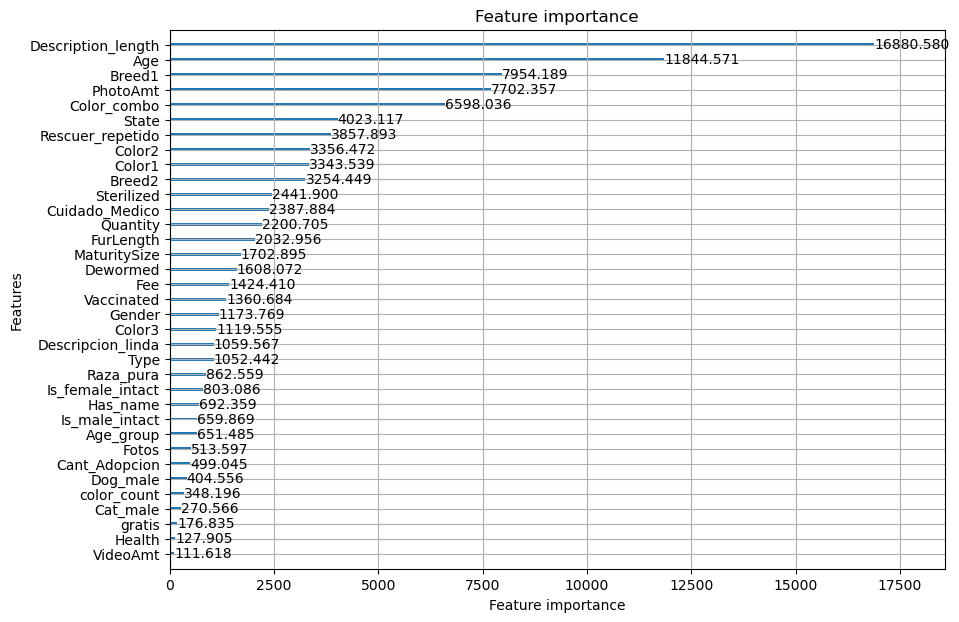

In [11]:
#Inicio el store de artefactos (archivos) de optuna
artifact_store = FileSystemArtifactStore(base_path=PATH_TO_OPTUNA_ARTIFACTS)

#Genero estudio
study = optuna.create_study(direction='maximize',
                            storage="sqlite:///../work/db.sqlite3",  # Specify the storage URL here.
                            study_name="3 - FE Manual",
                            load_if_exists = True)
#Corro la optimizacion
study.optimize(cv_es_lgb_objective, n_trials=100)

### Modelo Final

In [12]:
#Vamos a replicar el resultado de la optimizacion reentrenando el modelo con el mejor conjunto de hiperparametros
#Generamos parametros incluyendo los fijos y la mejor solución que encontro optuna
lgb_params =  {      
                        'objective': 'multiclass',
                        'verbosity':-1,
                        'num_class': len(y_train.unique())} | study.best_params

lgb_train_dataset = lgb.Dataset(data=X_train,
                                label=y_train)


#Entreno
lgb_model = lgb.train(lgb_params,
                    lgb_train_dataset)

#Muestro matriz de confusion y kappa
display(plot_confusion_matrix(y_test,lgb_model.predict(X_test).argmax(axis=1)))

cohen_kappa_score(y_test,lgb_model.predict(X_test).argmax(axis=1),
                             weights = 'quadratic')

0.3740154957595392

## Datos imágenes

### Librerías

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import os
import shutil
import time
import copy
import datetime
from tqdm import tqdm

import optuna
from optuna.artifacts import FileSystemArtifactStore, upload_artifact

import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
import torch.nn.functional as F

from joblib import load, dump

from utils import plot_confusion_matrix
# Verificamos que CUDA está funcional
torch.cuda.is_available()

False

### Modelo preentrenado (ResNet50)

In [14]:
# Importo modelo ResNet entrenado en Imagenet
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# Modificar la última capa para adaptarse a tu problema específico
num_ftrs = resnet50.fc.in_features
resnet50.fc = torch.nn.Linear(num_ftrs, 5) # Clasificación 5 clases
# Configuro para usar cuda si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)
# Instancio del criterio de pérdida CrossEntropyLoss
criterion = nn.CrossEntropyLoss()


### Path

In [ ]:
# Paths
BASE_DIR = '../'
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train/train.csv")
PATH_TO_IMAGES_DIR = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train_images")
PATH_TO_TEMP_FILES = os.path.join(BASE_DIR, "work/optuna_temp_artifacts")
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(BASE_DIR, "work/optuna_artifacts")

MODEL_NAME = '04 ResNet'

MODEL_VERSION = '1.0.0'

# Parametros y variables
CREATE_PYTORCH_DIRECTORIES = 1
SEED = 20001101
BATCH_SIZE = 50
TEST_SIZE = 0.2
IMAGE_SIZE = 299
CPU_CORES = os.cpu_count()

# Armo el nuevo directorio de train
new_train_directory = os.path.join(BASE_DIR, 'work/train_images_classes')
os.makedirs(new_train_directory, exist_ok=True) # si ya existe el nombre, lo deja como está

# Armo el nuevo directorio de validación
new_val_directory = os.path.join(BASE_DIR, 'work/val_images_classes')
os.makedirs(new_val_directory, exist_ok=True)

# Definir las clases ordenadas
class_names = ['0', '1', '2', '3', '4']

# Mapear las etiquetas de las clases a números enteros consecutivos
class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

# Creo las carpetas de clases dentro de los directorios
for clase in class_names: # Una para cada clase
   os.makedirs(os.path.join(new_train_directory, str(clase)), exist_ok=True)
   os.makedirs(os.path.join(new_val_directory, str(clase)), exist_ok=True)


### Carga y Preprocesamiento

In [16]:
def visualize_pet(pet_id):
    path_to_image = os.path.join(PATH_TO_IMAGES_DIR, f'{pet_id}-1.jpg') # Irá a la primera imagen de la mascota
    # Cargar la imagen
    image_to_show = cv2.imread(path_to_image)
    # Convertir a formato RGB
    image_to_show = cv2.cvtColor(image_to_show, cv2.COLOR_BGR2RGB)
    # Visualizar la imagen
    plt.imshow(image_to_show)
    plt.axis('off')  # No mostrar los ejes
    plt.show()

def visualize_image(image):
    # Convierte la imagen a un formato de enteros (CV_8U)
    image = cv2.convertScaleAbs(image)
    image= cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Visualizar la imagen
    plt.imshow(image.astype(np.uint8))
    plt.axis('off')  # No mostrar los ejes
    plt.show()

In [ ]:

if CREATE_PYTORCH_DIRECTORIES == 1: # Poner en 0 si ya tengo las carpetas train_images_classes y val_images_classes con las imágenes copiadas
    # Función para copiar las imágenes a los directorios correspondientes
    def copy_imag(data, directorio_destino):
        for index, row in data.iterrows():
            petID = row['PetID']
            adoption_speed = row['AdoptionSpeed']
            
            # Nombre del archivo de imagen
            nombre_archivo = f"{petID}-1.jpg"
            
            # Ruta completa de la imagen de origen
            ruta_origen = os.path.join(PATH_TO_IMAGES_DIR, nombre_archivo)
            
            # Ruta completa del directorio de destino
            ruta_destino = os.path.join(directorio_destino, str(adoption_speed), nombre_archivo)
            
            # Verificar si el archivo de origen existe
            if os.path.exists(ruta_origen):
                # Copiar el archivo de origen al directorio de destino
                shutil.copy2(ruta_origen, ruta_destino)
        print("Completada la copia a: ",str(directorio_destino))

    # Copiar las imágenes al directorio de train
    copy_imag(train, new_train_directory)

    # Copiar las imágenes al directorio de val
    copy_imag(test, new_val_directory)

    print("Proceso completado.")

Completada la copia a:  ../work/train_images_classes
Completada la copia a:  ../work/val_images_classes
Proceso completado.
